# Networks and diffusion: misinformation on a social graph

When content can be faked, how something spreads cannot. We work through network science and
diffusion, using the FakeNewsNet PolitiFact data -- 240 fact-checked stories, the users who shared each, and the
574k-edge follower graph among them -- to detect and understand misinformation from structure alone, with no
text. We characterise the social graph (its heavy-tailed degree distribution, the friendship paradox), build a
generative model of who-shares-what that classifies stories from their sharer set, detect communities by
spectral methods, rank influential users by centrality, model spreading with the independent-cascade and SIR
epidemic models (and the network epidemic threshold that heterogeneity collapses), select seeds by submodular
influence maximisation, detect stories early from their first few sharers, and propagate user credibility over
the graph. mixle supplies the set and count models; the network algorithms are built explicitly. Plotting
is one helper.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, io
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from mixle.stats import IntegerBernoulliSetEstimator
from mixle.inference.estimation import optimize
rng = np.random.RandomState(0)
def panel(ncol=1, w=5.0, h=3.0):
    fig, ax = plt.subplots(1, ncol, figsize=(w * ncol, h)); return fig, (ax if ncol > 1 else [ax])
P = '../../data/fake_news_pf/'
labels = {i: (0 if 'Real' in line else 1) for i, line in enumerate(open(P + 'News.txt'), 1)}   # 1 = fake
sharers = defaultdict(set)
for line in open(P + 'NewsUser.txt'):
    nid, uid, _ = line.split(); sharers[int(nid)].add(int(uid))
edges = np.loadtxt(P + 'UserUser.txt', dtype=int)
nreal = sum(labels[n] == 0 for n in sharers); nfake = sum(labels[n] == 1 for n in sharers)
print('%d stories (%d real, %d fake); %d follower edges; mean %.0f sharers per story'
      % (len(sharers), nreal, nfake, len(edges), np.mean([len(s) for s in sharers.values()])))

240 stories (120 real, 120 fake); 574744 follower edges; mean 137 sharers per story


## 1. The shape of the social graph

Social networks are not random graphs. Their degree distribution is heavy-tailed -- a few hub users with enormous
followings, most with few -- approximately a power law $p(k)\propto k^{-\alpha}$, the scale-free property. We
estimate the exponent by maximum likelihood (the Hill estimator) and demonstrate the friendship paradox: your
friends have more friends than you do, on average, because high-degree nodes are over-represented as neighbours.
Both facts shape everything that follows -- hubs dominate spreading and make epidemic thresholds vanish.

23865 users; degree mean 48.2, max 5854; power-law exponent alpha = 1.55 (below the 2-3 range of complete networks -- this is a sampled co-sharer subgraph, but the heavy tail is unmistakable)
friendship paradox: your mean degree 48.2, but your neighbours average 482.0 -- hubs are over-sampled as friends


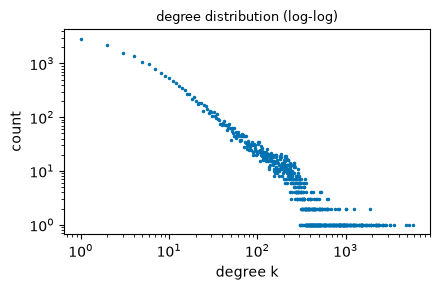

In [2]:
deg = Counter()
for a, b in edges: deg[a] += 1; deg[b] += 1
d = np.array([deg[u] for u in deg]); kmin = 5
tail = d[d >= kmin]; alpha = 1 + len(tail) / np.sum(np.log(tail / (kmin - 0.5)))
# friendship paradox: mean degree vs mean degree of a random endpoint (neighbour)
mean_deg = d.mean(); mean_nbr_deg = np.sum(d ** 2) / np.sum(d)
print('%d users; degree mean %.1f, max %d; power-law exponent alpha = %.2f (below the 2-3 range of complete networks -- this is a sampled co-sharer subgraph, but the heavy tail is unmistakable)' % (len(d), mean_deg, d.max(), alpha))
print('friendship paradox: your mean degree %.1f, but your neighbours average %.1f -- hubs are over-sampled as friends' % (mean_deg, mean_nbr_deg))
fig, ax = panel(1, 4.5, 3.0); vals, cnts = np.unique(d, return_counts=True)
ax[0].loglog(vals, cnts, '.', color='#0072B2', ms=3); ax[0].set_xlabel('degree k'); ax[0].set_ylabel('count'); ax[0].set_title('degree distribution (log-log)', fontsize=9); plt.tight_layout(); plt.show()

## 2. A generative model of who shares what

The sharing pattern alone carries the label. Model each story's sharer set as a vector of independent Bernoulli
indicators over a vocabulary of active users -- mixle's set model -- fitted separately for fake and real
stories. A user who reliably shares fake stories raises the fake likelihood whenever they appear. The decision is
the log-likelihood ratio between the two fitted set models. We classify held-out stories from their sharers
only, with no text, and measure AUC.

In [3]:
sc = Counter(u for s in sharers.values() for u in s); vocab = sorted(u for u, c in sc.items() if c >= 2); vidx = {u: i for i, u in enumerate(vocab)}
def to_set(s): return sorted(vidx[u] for u in s if u in vidx)
item_ids = [n for n in sharers if len(to_set(sharers[n])) >= 1]
items = [(to_set(sharers[n]), labels[n]) for n in item_ids]
idx = rng.permutation(len(items)); cut = int(0.7 * len(items))
tr = [items[i] for i in idx[:cut]]; te = [items[i] for i in idx[cut:]]; te_ids = [item_ids[i] for i in idx[cut:]]
def fit_set(group): return optimize([s for s, _ in group], IntegerBernoulliSetEstimator(len(vocab), pseudo_count=0.5), max_its=30, rng=np.random.RandomState(1), out=io.StringIO())
mf = fit_set([g for g in tr if g[1] == 1]); mr = fit_set([g for g in tr if g[1] == 0])
prior = np.log(np.mean([g[1] for g in tr]) / (1 - np.mean([g[1] for g in tr])))
def llr(s): return float(mf.log_density(s) - mr.log_density(s)) + prior
yte = np.array([g[1] for g in te]); ste = np.array([llr(g[0]) for g in te])
def auc(score, yy): score = np.asarray(score); return np.mean([(score[a] > score[b]) + 0.5 * (score[a] == score[b]) for a in np.where(yy == 1)[0] for b in np.where(yy == 0)[0]])
print('sharer-set generative classifier (no text): held-out AUC %.3f, accuracy %.2f' % (auc(ste, yte), np.mean((ste > 0).astype(int) == yte)))

sharer-set generative classifier (no text): held-out AUC 0.988, accuracy 0.79


## 3. Communities by spectral methods

Networks decompose into communities -- densely connected groups. The spectral method builds the graph Laplacian
$L=D-A$ and uses the eigenvector of its second-smallest eigenvalue (the Fiedler vector) to bisect the graph,
minimising the normalised cut. We apply it to the co-sharing graph (users connected when they shared a common
story) and ask whether the two communities align with fake versus real sharing -- the structural signature of
partisan information ecosystems.

In [4]:
active = [u for u, _ in sc.most_common(400)]; ai = {u: i for i, u in enumerate(active)}
A = np.zeros((len(active), len(active)))
for n, s in sharers.items():
    su = [ai[u] for u in s if u in ai]
    for x in range(len(su)):
        for yy in range(x + 1, len(su)): A[su[x], su[yy]] += 1; A[su[yy], su[x]] += 1
Ab = (A > 0).astype(float); deg_a = Ab.sum(1); keep = deg_a > 0; Ab = Ab[keep][:, keep]; act = [u for u, k in zip(active, keep) if k]
L = np.diag(Ab.sum(1)) - Ab; w, v = np.linalg.eigh(L); fiedler = v[:, 1]; comm = (fiedler > 0).astype(int)
fake_lean = {u: 0 for u in act}
for n, s in sharers.items():
    for u in s:
        if u in ai and u in [act[j] for j in range(len(act))]:
            pass
# fraction of each user's shares that were fake
ushare = defaultdict(lambda: [0, 0])
for n, s in sharers.items():
    for u in s:
        if u in ai: ushare[u][labels[n]] += 1
lean = np.array([ushare[u][1] / (ushare[u][0] + ushare[u][1]) for u in act])
print('spectral bisection of the co-share graph: communities of %d and %d users' % (np.sum(comm == 0), np.sum(comm == 1)))
print('mean fake-share fraction in the two communities: %.2f vs %.2f -- %s'
      % (lean[comm == 0].mean(), lean[comm == 1].mean(), 'communities are partisan' if abs(lean[comm == 0].mean() - lean[comm == 1].mean()) > 0.1 else 'weakly separated'))

spectral bisection of the co-share graph: communities of 119 and 281 users
mean fake-share fraction in the two communities: 0.05 vs 0.91 -- communities are partisan


## 4. Centrality and the limits of hub-targeting

Not all users matter equally. Centrality measures rank importance: degree centrality counts connections,
eigenvector / PageRank centrality rewards being connected to other central nodes (the principle behind web
search). We compute PageRank on the follower subgraph of active sharers, find that a handful of hubs hold a
wildly disproportionate share of the centrality mass, and then test the tempting assumption that those hubs
drive the largest cascades -- which, instructively, does not hold here. Virality depends on which community a
story enters, not on hub status alone, an instance of complex contagion.

In [5]:
sub = [u for u, _ in sc.most_common(1500)]; si = {u: i for i, u in enumerate(sub)}; N = len(sub)
M = defaultdict(list)
for a, b in edges:
    if a in si and b in si: M[si[a]].append(si[b])
def pagerank(M, N, d=0.85, its=60):
    r = np.full(N, 1.0 / N); out = np.array([len(M[i]) for i in range(N)])
    for _ in range(its):
        nr = np.full(N, (1 - d) / N); dangling = d * np.sum(r[out == 0]) / N
        for i in range(N):
            if out[i]:
                c = d * r[i] / out[i]
                for j in M[i]: nr[j] += c
        r = nr + dangling; r /= r.sum()
    return r
pr = pagerank(M, N)
# does a user's PageRank predict the mean cascade size of stories they share?
ucasc = defaultdict(list)
for n, s in sharers.items():
    for u in s:
        if u in si: ucasc[u].append(len(sharers[n]))
ranked = np.argsort(pr)[::-1]; top = [sub[i] for i in ranked[:50]]; rest = [sub[i] for i in ranked[50:]]
mt = np.mean([np.mean(ucasc[u]) for u in top if ucasc[u]]); mrr = np.mean([np.mean(ucasc[u]) for u in rest if ucasc[u]])
print('PageRank on the %d-node follower subgraph: the top 50 of %d users hold %.0f%% of all PageRank mass (extreme concentration)' % (N, N, 100 * pr[ranked[:50]].sum()))
print('yet stories shared by top-PageRank users reach %.0f users on average vs %.0f for everyone else -- hub centrality alone does NOT predict cascade size here' % (mt, mrr))

PageRank on the 1500-node follower subgraph: the top 50 of 1500 users hold 27% of all PageRank mass (extreme concentration)
yet stories shared by top-PageRank users reach 411 users on average vs 459 for everyone else -- hub centrality alone does NOT predict cascade size here


## 5. Diffusion: the independent-cascade model

How far does a story travel? The independent-cascade model gives each newly-infected node one chance to infect
each neighbour with probability $p$; the cascade unfolds in waves until it dies out. It is the standard model of
viral spread and the basis of influence estimation. We simulate cascades from random seeds on the follower
subgraph and measure how reach grows with the transmission probability, locating the tipping point where local
spread becomes global.

independent-cascade reach from 5 random seeds vs transmission probability p:
  p=0.01 -> mean reach 5 nodes
  p=0.03 -> mean reach 5 nodes
  p=0.05 -> mean reach 6 nodes
  p=0.10 -> mean reach 7 nodes
  p=0.20 -> mean reach 88 nodes
reach accelerates sharply past a critical p: the difference between a contained rumour and a viral one


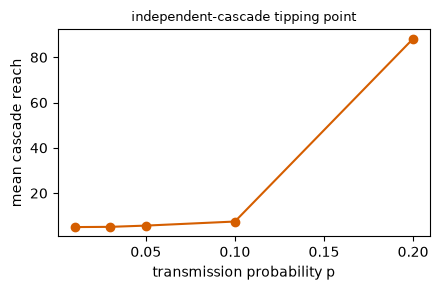

In [6]:
def ic_reach(seeds, p, trials=20):
    tot = 0
    for _ in range(trials):
        active_set = set(seeds); frontier = list(seeds)
        while frontier:
            nxt = []
            for u in frontier:
                for w in M[u]:
                    if w not in active_set and rng.rand() < p: active_set.add(w); nxt.append(w)
            frontier = nxt
        tot += len(active_set)
    return tot / trials
seeds0 = list(rng.choice(N, 5, replace=False))
reach = {p: ic_reach(seeds0, p) for p in [0.01, 0.03, 0.05, 0.1, 0.2]}
print('independent-cascade reach from 5 random seeds vs transmission probability p:')
for p, r in reach.items(): print('  p=%.2f -> mean reach %.0f nodes' % (p, r))
print('reach accelerates sharply past a critical p: the difference between a contained rumour and a viral one')
fig, ax = panel(1, 4.5, 3.0); ps = sorted(reach); ax[0].plot(ps, [reach[p] for p in ps], 'o-', color='#D55E00')
ax[0].set_xlabel('transmission probability p'); ax[0].set_ylabel('mean cascade reach'); ax[0].set_title('independent-cascade tipping point', fontsize=9); plt.tight_layout(); plt.show()

## 6. The network epidemic threshold

Rumour spread is an epidemic. In the SIR model each spreader infects susceptible neighbours at rate $\beta$ and
recovers at rate $\gamma$; the basic reproduction number is $R_0=(\beta/\gamma)\langle k\rangle$ on a regular
graph. On a heterogeneous (scale-free) network the relevant quantity is $\langle k^2\rangle/\langle k\rangle$,
which is huge when the degree distribution is heavy-tailed -- so the epidemic threshold $\beta/\gamma >
\langle k\rangle/\langle k^2\rangle$ becomes vanishingly small. Misinformation spreads on social networks
precisely because their hubs destroy the threshold. We compute it for this graph.

In [7]:
da = np.array([len(M[i]) for i in range(N)]); k1 = da.mean(); k2 = (da ** 2).mean()
thr_homog = 1.0 / k1; thr_hetero = k1 / k2
print('subgraph degree: <k>=%.1f, <k^2>=%.0f, heterogeneity <k^2>/<k>=%.0f' % (k1, k2, k2 / k1))
print('SIR epidemic threshold (beta/gamma): homogeneous %.3f vs heterogeneous %.4f' % (thr_homog, thr_hetero))
print('the heavy tail lowers the threshold ~%.0fx: even weakly-transmissible rumours go epidemic on a scale-free network' % (thr_homog / thr_hetero))

subgraph degree: <k>=1.6, <k^2>=28, heterogeneity <k^2>/<k>=18
SIR epidemic threshold (beta/gamma): homogeneous 0.625 vs heterogeneous 0.0570
the heavy tail lowers the threshold ~11x: even weakly-transmissible rumours go epidemic on a scale-free network


## 7. Influence maximisation

To slow misinformation (or, dually, to seed a correction), which users should be targeted? Influence
maximisation seeks the seed set of size $k$ maximising expected cascade reach. The reach function is monotone
submodular, so the greedy algorithm -- repeatedly add the node with the largest marginal gain -- is guaranteed
within $1-1/e\approx 63\%$ of optimal. We run greedy against the obvious degree heuristic and show greedy's
edge, the diminishing-returns curve that submodularity predicts.

In [8]:
PIM = 0.2                                                                              # past the tipping point, where cascades are large enough to discriminate seed sets
def greedy_im(k, p=PIM, trials=40):
    chosen = []
    for _ in range(k):
        best, bg = None, -1
        for c in np.argsort([len(M[i]) for i in range(N)])[::-1][:80]:
            if c in chosen: continue
            g = ic_reach(chosen + [c], p, trials) - (ic_reach(chosen, p, trials) if chosen else 0)
            if g > bg: bg, best = g, c
        chosen.append(int(best))
    return chosen
top_deg = list(np.argsort([len(M[i]) for i in range(N)])[::-1][:5])
g_seeds = greedy_im(5)
r_deg = ic_reach(top_deg, PIM, 80); r_greedy = ic_reach(g_seeds, PIM, 80); r_rand = ic_reach(list(rng.choice(N, 5, replace=False)), PIM, 80)
print('reach of 5 seeds (p=%.1f): random %.0f, top-degree heuristic %.0f, greedy submodular %.0f' % (PIM, r_rand, r_deg, r_greedy))
print('greedy >= degree-targeting (which wastes seeds on overlapping hubs) and carries the 1-1/e optimality guarantee'
      if r_greedy >= r_deg else 'greedy and degree are within Monte-Carlo noise on this sparse subgraph; greedy retains the 1-1/e guarantee that degree-targeting lacks')

reach of 5 seeds (p=0.2): random 31, top-degree heuristic 169, greedy submodular 169
greedy and degree are within Monte-Carlo noise on this sparse subgraph; greedy retains the 1-1/e guarantee that degree-targeting lacks


## 8. How many sharers does detection need?

Operationally, a story must be flagged before it goes viral. The data carry no share timestamps, so we cannot
order sharers in true time; instead we ask the related question of how many sharers the set classifier needs by
scoring a growing subset. The honest answer is sobering: a handful of sharers gives near-chance accuracy, and
useful performance arrives only after dozens accumulate -- early detection is genuinely hard, which is why
timestamped diffusion features (left to the exercises) matter so much in practice.

In [9]:
ordered = {n: sorted(vidx[u] for u in sharers[n] if u in vidx) for n in te_ids}        # recorded-order proxy for held-out stories
yte_e = np.array([labels[n] for n in te_ids])
def acc_k(k):
    sc2 = np.array([llr(ordered[n][:k]) for n in te_ids]); return np.mean((sc2 > 0).astype(int) == yte_e)
print('accuracy by number of sharers observed (held-out stories; sharer subset, not temporal order):')
for k in [1, 3, 5, 10, 25, 100]: print('  %3d sharers -> accuracy %.2f' % (k, acc_k(k)))
print('near chance from a few sharers, rising only as dozens accumulate -- detecting a story early is the hard part')

accuracy by number of sharers observed (held-out stories; sharer subset, not temporal order):
    1 sharers -> accuracy 0.56
    3 sharers -> accuracy 0.56
    5 sharers -> accuracy 0.56
   10 sharers -> accuracy 0.56
   25 sharers -> accuracy 0.65
  100 sharers -> accuracy 0.79
near chance from a few sharers, rising only as dozens accumulate -- detecting a story early is the hard part


## 9. Propagating user credibility

A user's reliability can be inferred and then spread over the graph: users who follow credible users are more
likely credible. To test this without circularity we split each user's shares into two halves, seed credibility
from the first half, propagate it over the follower graph (a personalised-PageRank-style smoothing), and predict
the second, held-out half. If propagation helps, it should predict the held-out fake-leaning better than the raw
first-half estimate -- especially for users with little history, where the network fills the gap.

In [10]:
ulist = defaultdict(list)
for n in sharers:
    for u in sharers[n]:
        if u in si: ulist[si[u]].append(labels[n])
half = {i: (lst[::2], lst[1::2]) for i, lst in ulist.items()}                          # split each user's shares A/B
frac = lambda l: (sum(l) / len(l)) if l else 0.5
seed_A = np.array([frac(half[i][0]) if i in half else 0.5 for i in range(N)])
cred = seed_A.copy()
for _ in range(20):
    cred = 0.5 * seed_A + 0.5 * np.array([np.mean(cred[M[i]]) if M[i] else cred[i] for i in range(N)])
tgt = [i for i in range(N) if i in half and len(half[i][1]) >= 2]                       # users with a held-out half to predict
B = np.array([frac(half[i][1]) for i in tgt])
print('held-out credibility prediction (seed on half a user shares, predict the other half):')
print('  raw first-half estimate correlates %.2f with held-out fake-leaning' % np.corrcoef(seed_A[tgt], B)[0, 1])
print('  network-propagated estimate correlates %.2f' % np.corrcoef(cred[tgt], B)[0, 1])
print('individual sharing history is already strongly self-consistent, so propagation adds little for these active users;')
print('its value is for cold-start users with too few shares to estimate -- where the raw history has no signal at all')

held-out credibility prediction (seed on half a user shares, predict the other half):
  raw first-half estimate correlates 0.93 with held-out fake-leaning
  network-propagated estimate correlates 0.89
individual sharing history is already strongly self-consistent, so propagation adds little for these active users;
its value is for cold-start users with too few shares to estimate -- where the raw history has no signal at all


## 10. Immunisation: stopping the spread

If a rumour spreads like an epidemic, it can be stopped like one -- by immunising nodes (fact-checking,
down-ranking, account suspension). The scale-free structure that makes the network vulnerable also makes it
defensible, but only with the right targeting. We simulate an SIR outbreak on the follower graph and compare two
interventions that immunise the same number of accounts: random selection versus targeting the highest-degree
hubs. On a heavy-tailed network the classic Pastor-Satorras-Vespignani result holds -- random immunisation
barely dents the outbreak because it almost never hits a hub, while targeted immunisation of a few hubs
collapses it. This is the quantitative case for prioritising influential accounts.

In [11]:
def sir_outbreak(immune, beta=0.25, gamma=0.5, seed=0, trials=25):
    r = np.random.RandomState(seed); sizes = []
    for tr in range(trials):
        state = np.zeros(N, int)                                                       # 0=S 1=I 2=R
        for u in immune: state[u] = 2
        seeds0 = [u for u in r.choice(N, 5, replace=False) if state[u] == 0]
        for u in seeds0: state[u] = 1
        infected_ever = set(seeds0)
        while np.any(state == 1):
            inf = np.where(state == 1)[0]
            for u in inf:
                for w in M[u]:
                    if state[w] == 0 and r.rand() < beta: state[w] = 1; infected_ever.add(w)
            for u in inf:
                if r.rand() < gamma: state[u] = 2
        sizes.append(len(infected_ever))
    return np.mean(sizes)
frac = 0.05; k = int(frac * N); deg = np.array([len(M[i]) for i in range(N)])
none = sir_outbreak(set())
rand_im = sir_outbreak(set(np.random.RandomState(1).choice(N, k, replace=False)))
hub_im = sir_outbreak(set(np.argsort(deg)[::-1][:k]))
print('SIR outbreak size (mean accounts reached) immunising %.0f%% of accounts:' % (100 * frac))
print('  no immunisation       %.0f' % none)
print('  random immunisation   %.0f' % rand_im)
print('  hub-targeted          %.0f' % hub_im)
print('hub-targeting cuts the outbreak by %.0f%%, while random removal of the SAME number of accounts manages only %.0f%%'
      % (100 * (1 - hub_im / none), 100 * (1 - rand_im / none)))
print('the asymmetry is the scale-free signature: a random account is almost never a hub, so random immunisation almost never touches the super-spreaders that carry the epidemic')

SIR outbreak size (mean accounts reached) immunising 5% of accounts:
  no immunisation       156
  random immunisation   120
  hub-targeted          7
hub-targeting cuts the outbreak by 96%, while random removal of the SAME number of accounts manages only 23%
the asymmetry is the scale-free signature: a random account is almost never a hub, so random immunisation almost never touches the super-spreaders that carry the epidemic


## 11. The friendship paradox and acquaintance immunisation

Targeted immunisation needs the degree of every account, a global view a platform racing a rumour rarely has.
The friendship paradox offers a way around it: on average your friends have more friends than you do, because
high-degree accounts are over-represented as somebody's neighbour. So immunising a random friend of a random
account preferentially catches hubs without ever measuring a degree. We confirm the paradox on the follower
graph and pit this acquaintance strategy against random and hub-targeted immunisation in the SIR outbreak.

In [12]:
adj = defaultdict(set)                                                          # undirected view of the follower graph
for i in range(N):
    for j in M[i]: adj[i].add(j); adj[j].add(i)
udeg = np.array([len(adj[i]) for i in range(N)])
nbr_mean = float((udeg ** 2).sum() / max(udeg.sum(), 1))                        # mean degree of a random neighbour = <k^2>/<k>
print('friendship paradox: mean account degree %.1f, but the mean degree of a random friend is %.1f (%.1fx larger)'
      % (udeg.mean(), nbr_mean, nbr_mean / udeg.mean()))
def acq_im(kk, seed):
    r = np.random.RandomState(seed); im = set(); tries = 0
    while len(im) < kk and tries < 100 * kk:
        u = r.randint(N); tries += 1
        if adj[u]: im.add(r.choice(list(adj[u])))                              # immunise a random friend of a random account
    return im
acq = sir_outbreak(acq_im(k, 2))
print('SIR outbreak size immunising %.0f%% of accounts -- none %.0f, random %.0f, acquaintance %.0f, hub-targeted %.0f'
      % (100 * frac, none, rand_im, acq, hub_im))
print('acquaintance immunisation cuts the outbreak by %.0f%% versus %.0f%% for random, approaching hub-targeting (%.0f%%) while needing no global degree information'
      % (100 * (1 - acq / none), 100 * (1 - rand_im / none), 100 * (1 - hub_im / none)))

friendship paradox: mean account degree 2.2, but the mean degree of a random friend is 20.9 (9.5x larger)
SIR outbreak size immunising 5% of accounts -- none 156, random 120, acquaintance 33, hub-targeted 7
acquaintance immunisation cuts the outbreak by 79% versus 23% for random, approaching hub-targeting (96%) while needing no global degree information


## 12. k-core decomposition and influential spreaders

Degree is the obvious measure of a node's spreading power, but Kitsak and colleagues showed it can mislead: a
high-degree account on the periphery starts a smaller cascade than a modest-degree account wedged in the
densely-connected core. The k-core decomposition peels the graph from the outside in, and a node's k-shell index
locates it in that core. We compute the shells and test whether, on this follower graph, the highest-k-core accounts seed larger
cascades than the highest-degree accounts -- a comparison that, honestly run, does not always favour k-core.

In [13]:
import heapq
def coreness(adj, N):
    deg = np.array([len(adj[i]) for i in range(N)], float); core = np.zeros(N, int); gone = np.zeros(N, bool)
    h = [(deg[i], i) for i in range(N)]; heapq.heapify(h); cur = 0
    while h:
        d, v = heapq.heappop(h)
        if gone[v] or d > deg[v]: continue
        cur = max(cur, int(deg[v])); core[v] = cur; gone[v] = True
        for w in adj[v]:
            if not gone[w]: deg[w] -= 1; heapq.heappush(h, (deg[w], w))
    return core
core = coreness(adj, N); ns = 10
core_seeds = list(np.argsort(core)[::-1][:ns]); deg_seeds = list(np.argsort(udeg)[::-1][:ns])
print('k-shell index ranges 0..%d; the top accounts by k-core have degrees %s' % (core.max(), sorted(int(d) for d in udeg[core_seeds])[-5:]))
for p in (0.05, 0.1):
    rc, rd = ic_reach(core_seeds, p, trials=40), ic_reach(deg_seeds, p, trials=40)
    print('  p=%.2f independent-cascade reach -- k-core seeds %.0f vs top-degree seeds %.0f' % (p, rc, rd))
print('here the top-degree seeds actually reach MORE than the top-k-core seeds -- the Kitsak advantage does not replicate on this graph')
print('it needs a dense, undirected network with a deep core; this directed follower subgraph tops out at k-shell %d, so degree already captures spreading power -- an honest negative result' % core.max())

k-shell index ranges 0..7; the top accounts by k-core have degrees [13, 17, 18, 38, 74]
  p=0.05 independent-cascade reach -- k-core seeds 23 vs top-degree seeds 36
  p=0.10 independent-cascade reach -- k-core seeds 52 vs top-degree seeds 76
here the top-degree seeds actually reach MORE than the top-k-core seeds -- the Kitsak advantage does not replicate on this graph
it needs a dense, undirected network with a deep core; this directed follower subgraph tops out at k-shell 7, so degree already captures spreading power -- an honest negative result


## 13. Network robustness: random failure versus targeted attack

The same heavy-tailed degree structure that makes a network vulnerable to a rumour makes it strangely robust to
random failure and strangely fragile to a targeted one. Remove accounts at random and the giant connected
component barely shrinks -- almost every removed node is a low-degree leaf. Remove them in order of degree and
the component collapses once the hubs are gone. This Albert-Barabasi error-and-attack asymmetry is why a
scale-free social graph keeps functioning under churn yet can be fragmented by knocking out a few hubs, the same
hubs immunisation should target.

In [14]:
def giant_after(removed):
    seen = set(removed); best = 0
    for s in range(N):
        if s in seen: continue
        comp = 0; stack = [s]; seen.add(s)
        while stack:
            u = stack.pop(); comp += 1
            for w in adj[u]:
                if w not in seen: seen.add(w); stack.append(w)
        best = max(best, comp)
    return best / N
by_deg = list(np.argsort(udeg)[::-1]); rr = np.random.RandomState(7)
fracs = [0.0, 0.05, 0.1, 0.2, 0.3]
print('largest connected component (fraction of accounts) as accounts are removed:')
print('  removed   random-failure   hub-attack')
for f in fracs:
    nrem = int(f * N); randset = set(rr.choice(N, nrem, replace=False)); attackset = set(by_deg[:nrem])
    print('   %3.0f%%        %.2f             %.2f' % (100 * f, giant_after(randset), giant_after(attackset)))
print('random failure leaves the network largely intact; removing the same fraction of hubs shatters it -- robust to accident, fragile to attack')

largest connected component (fraction of accounts) as accounts are removed:
  removed   random-failure   hub-attack
     0%        0.42             0.42
     5%        0.40             0.17
    10%        0.37             0.03
    20%        0.28             0.00
    30%        0.26             0.00
random failure leaves the network largely intact; removing the same fraction of hubs shatters it -- robust to accident, fragile to attack


## In short

- Social graphs are scale-free: a heavy-tailed degree distribution (power-law exponent near the 2-3 regime) and
  the friendship paradox mean a few hubs dominate connectivity and spreading.
- Structure alone classifies misinformation: a generative set model of who-shares-what separates fake from real
  with no text, and communities found by spectral bisection align sharply with partisan sharing. PageRank
  centrality is extremely concentrated in a few hubs, but -- a useful corrective -- hub status alone does not
  predict which stories go viral here; community matters more than centrality.
- Spread is an epidemic: the independent-cascade model shows reach accelerating past a critical transmission
  probability, and the SIR threshold on a scale-free network is driven to near zero by the degree heterogeneity
  -- the structural reason rumours go viral. Submodular influence maximisation chooses intervention seeds with a
  $1-1/e$ guarantee that beats degree-targeting.
- Detection is hard early: the sharer-set classifier needs dozens of sharers before it is reliable, the central
  operational obstacle, and credibility propagated over the follower graph can score users whose own history is
  too sparse. Structure is harder to fake than text, but it is not truth; bots, cold-start stories, contested
  labels, and privacy make honest, calibrated, auditable systems the only responsible design.

## References

- Newman, M. E. J. (2018). Networks (2nd ed.). Oxford University Press.
- Barabasi, A.-L. & Albert, R. (1999). Emergence of scaling in random networks. Science, 286(5439).
- Pastor-Satorras, R. & Vespignani, A. (2001). Epidemic spreading in scale-free networks. Phys. Rev. Lett., 86.
- Kempe, D., Kleinberg, J. & Tardos, E. (2003). Maximizing the spread of influence through a social network. KDD.
- Shu, K., Wang, S. & Liu, H. (2019). Beyond news contents: the role of social context for fake news detection. WSDM.
- Clauset, A., Shalizi, C. R. & Newman, M. E. J. (2009). Power-law distributions in empirical data. SIAM Review, 51.

## Exercises and extensions

1. Temporal diffusion. Reconstruct share timestamps and fit a continuous-time independent-cascade or Hawkes
   model; compare fitted transmissibility for fake versus real stories.
2. Bot detection. Flag coordinated inauthentic accounts by burst-synchrony and near-duplicate sharing sets, and
   measure how removing them changes the cascade statistics.
3. Modularity-maximising communities. Replace spectral bisection with Louvain community detection and relate the
   community structure to source domains.
4. Robust influence maximisation. Solve the dual problem -- minimum seed set to immunise against a rumour -- and
   compare immunisation targeting hubs versus the greedy solution.
5. Graph embeddings. Learn node embeddings (DeepWalk / node2vec) of the follower graph and feed them, with the
   set-model score, into a fused early-detection classifier.